Goal of this notebook: Generate 90 days of hourly sensor data for 81 monitored spaces (80 floor zones + 1 gym), calibrated to realistic ranges, with deliberate "story" anomalies baked in for the demo.

# Notebook 01: Synthetic Comfort & IAQ Data Generator

**Module A** of the smart-facility-pulse pilot.

Generates 90 days of hourly sensor readings for:
- 20 floors × 4 zones = 80 corridor zones
- 1 gymnasium (special zone)

Sensors per zone: indoor temperature, humidity, CO₂, PM2.5, CO, occupancy.

Output: `comfort_sensors.parquet` saved to Google Drive.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import os

from google.colab import drive
drive.mount('/content/drive')

PROJECT_ROOT = '/content/drive/MyDrive/smart-facility-pulse'
DATA_DIR = os.path.join(PROJECT_ROOT, 'data', 'synthetic')
os.makedirs(DATA_DIR, exist_ok=True)

np.random.seed(42)

print(f"✓ Project root: {PROJECT_ROOT}")
print(f"✓ Data directory: {DATA_DIR}")

Mounted at /content/drive
✓ Project root: /content/drive/MyDrive/smart-facility-pulse
✓ Data directory: /content/drive/MyDrive/smart-facility-pulse/data/synthetic


In [2]:
# Building structure
N_FLOORS = 20
QUADRANTS = ['NE', 'NW', 'SE', 'SW']

# Time range: 90 days of hourly data ending today
END_DATE = datetime(2026, 5, 2, 23, 0, 0)
START_DATE = END_DATE - timedelta(days=90)
TIMESTAMPS = pd.date_range(start=START_DATE, end=END_DATE, freq='h')

print(f"Time range: {START_DATE.date()}  →  {END_DATE.date()}")
print(f"Hourly readings per zone: {len(TIMESTAMPS):,}")
print(f"Total zones: {N_FLOORS * len(QUADRANTS) + 1} (80 floor zones + 1 gym)")
print(f"Estimated total rows: {(N_FLOORS * len(QUADRANTS) + 1) * len(TIMESTAMPS):,}")

Time range: 2026-02-01  →  2026-05-02
Hourly readings per zone: 2,161
Total zones: 81 (80 floor zones + 1 gym)
Estimated total rows: 175,041


In [3]:
zones = []

# 80 corridor zones across 20 floors
for floor in range(1, N_FLOORS + 1):
    for quadrant in QUADRANTS:
        zone_id = f"F{floor:02d}-{quadrant}"
        zones.append({
            'zone_id': zone_id,
            'floor': floor,
            'quadrant': quadrant,
            'zone_type': 'corridor',
            'fcu_id': f"FCU-{zone_id}",
            'temp_setpoint': 24.0,
            'baseline_occupancy': 0.25,  # corridors are mostly low-traffic
        })

# Gymnasium — special zone on ground floor
zones.append({
    'zone_id': 'GYM-01',
    'floor': 0,
    'quadrant': 'CENTRAL',
    'zone_type': 'gymnasium',
    'fcu_id': 'FCU-GYM-01',
    'temp_setpoint': 22.0,                # gyms are kept cooler
    'baseline_occupancy': 0.55,           # higher base + bigger swings
})

zones_df = pd.DataFrame(zones)
print(f"✓ Built zone master table: {len(zones_df)} zones")
zones_df.head(6)

✓ Built zone master table: 81 zones


,zone_id,floor,quadrant,zone_type,fcu_id,temp_setpoint,baseline_occupancy
0,F01-NE,1,NE,corridor,FCU-F01-NE,24.0,0.25
1,F01-NW,1,NW,corridor,FCU-F01-NW,24.0,0.25
2,F01-SE,1,SE,corridor,FCU-F01-SE,24.0,0.25
3,F01-SW,1,SW,corridor,FCU-F01-SW,24.0,0.25
4,F02-NE,2,NE,corridor,FCU-F02-NE,24.0,0.25
5,F02-NW,2,NW,corridor,FCU-F02-NW,24.0,0.25


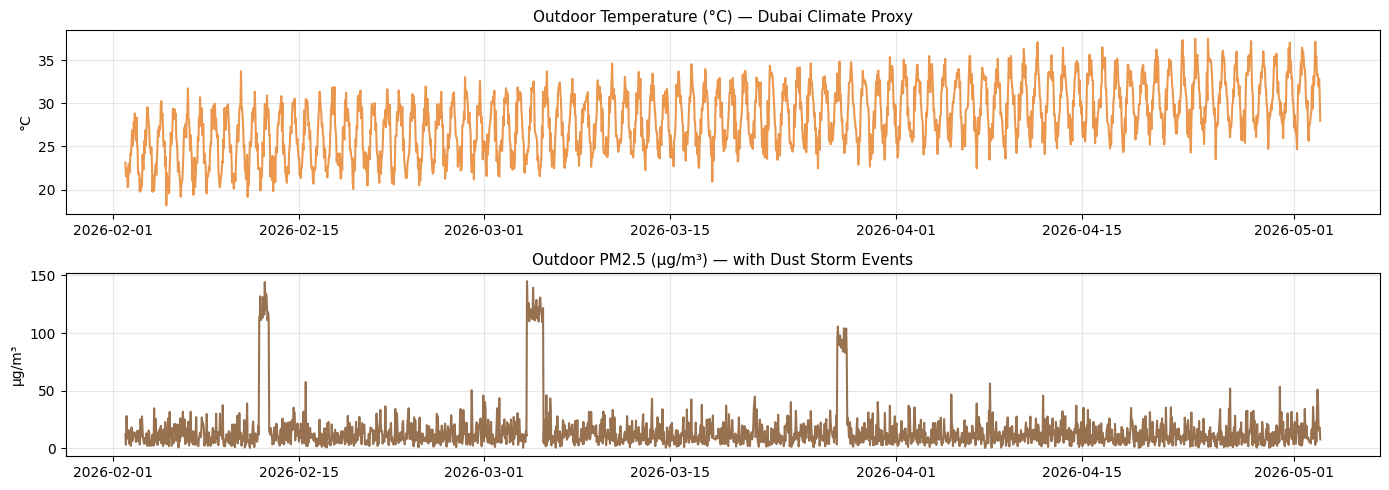

✓ Outdoor temp range: 18.2°C → 37.5°C
✓ Outdoor PM2.5 range: 0.2 → 145.0 µg/m³


In [4]:
hours = np.arange(len(TIMESTAMPS))
days_elapsed = hours / 24

# Seasonal trend: Feb is ~22°C, May is ~32°C average
seasonal = 27 + 5 * np.sin(2 * np.pi * (days_elapsed - 30) / 365)

# Daily cycle: ~8°C swing, peak ~3pm
hour_of_day = np.array([t.hour for t in TIMESTAMPS])
daily = 4 * np.sin(2 * np.pi * (hour_of_day - 9) / 24)

# Weather noise
noise = np.random.normal(0, 1.2, len(TIMESTAMPS))
outdoor_temp = seasonal + daily + noise

# Outdoor PM2.5: low baseline + 3 dust storm events
outdoor_pm25 = np.random.gamma(shape=2, scale=6, size=len(TIMESTAMPS))
for _ in range(3):
    storm_start = np.random.randint(100, len(TIMESTAMPS) - 60)
    storm_dur = np.random.randint(18, 48)
    storm_intensity = np.random.uniform(60, 130)
    outdoor_pm25[storm_start:storm_start + storm_dur] += storm_intensity

weather_df = pd.DataFrame({
    'timestamp': TIMESTAMPS,
    'outdoor_temp': np.round(outdoor_temp, 2),
    'outdoor_pm25': np.round(outdoor_pm25, 1),
})

# Visualize
fig, axes = plt.subplots(2, 1, figsize=(14, 5))
axes[0].plot(weather_df['timestamp'], weather_df['outdoor_temp'], color='#E67E22', alpha=0.8)
axes[0].set_title('Outdoor Temperature (°C) — Dubai Climate Proxy', fontsize=11)
axes[0].set_ylabel('°C'); axes[0].grid(alpha=0.3)

axes[1].plot(weather_df['timestamp'], weather_df['outdoor_pm25'], color='#7F4F24', alpha=0.8)
axes[1].set_title('Outdoor PM2.5 (µg/m³) — with Dust Storm Events', fontsize=11)
axes[1].set_ylabel('µg/m³'); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"✓ Outdoor temp range: {outdoor_temp.min():.1f}°C → {outdoor_temp.max():.1f}°C")
print(f"✓ Outdoor PM2.5 range: {outdoor_pm25.min():.1f} → {outdoor_pm25.max():.1f} µg/m³")

In [5]:
def generate_zone_readings(zone_row, weather_df, timestamps):
    """Generate 90 days of hourly sensor data for one zone."""
    n = len(timestamps)
    hours = np.array([t.hour for t in timestamps])
    days = np.array([t.dayofweek for t in timestamps])  # 0=Mon, 6=Sun

    # --- Occupancy pattern ---
    if zone_row['zone_type'] == 'gymnasium':
        # Bimodal: morning (6-9am) + evening (5-10pm) peaks
        morn = np.exp(-((hours - 7) ** 2) / 4)
        eve = np.exp(-((hours - 19) ** 2) / 6)
        time_factor = morn + eve
    else:
        # Corridor: morning + evening rush, low overnight
        morn = np.exp(-((hours - 8) ** 2) / 8)
        eve = np.exp(-((hours - 19) ** 2) / 8)
        time_factor = 0.3 + morn + eve  # base traffic + peaks

    weekend_boost = np.where(days >= 5, 1.25, 1.0)
    occupancy = zone_row['baseline_occupancy'] * time_factor * weekend_boost
    occupancy += np.random.normal(0, 0.04, n)
    occupancy = np.clip(occupancy, 0, 1)

    # --- Indoor temperature ---
    # Healthy AC keeps temp near setpoint, with small variation from outdoor
    # and occupancy heat load
    setpoint = zone_row['temp_setpoint']
    outdoor_pull = 0.04 * (weather_df['outdoor_temp'].values - setpoint)
    occupancy_heat = 1.2 * occupancy
    indoor_temp = setpoint + outdoor_pull + occupancy_heat + np.random.normal(0, 0.3, n)

    # --- Humidity (anti-correlated with cooling effort) ---
    base_humidity = 50
    humidity = base_humidity - 0.3 * (indoor_temp - setpoint) + 8 * occupancy
    humidity += np.random.normal(0, 2, n)
    humidity = np.clip(humidity, 25, 80)

    # --- CO2 (driven by occupancy + ventilation) ---
    base_co2 = 420
    co2 = base_co2 + 800 * occupancy + np.random.normal(0, 25, n)
    co2 = np.clip(co2, 400, 2500)

    # --- PM2.5 (outdoor influence + filtration) ---
    filtration_efficiency = 0.7  # healthy filter blocks 70%
    indoor_pm25 = (1 - filtration_efficiency) * weather_df['outdoor_pm25'].values
    indoor_pm25 += np.random.normal(0, 1.5, n)
    indoor_pm25 = np.clip(indoor_pm25, 0, 100)

    # --- CO (low baseline + occasional small spikes) ---
    co_level = np.random.gamma(shape=1.5, scale=0.5, size=n)
    co_level = np.clip(co_level, 0, 9)

    return pd.DataFrame({
        'timestamp': timestamps,
        'zone_id': zone_row['zone_id'],
        'floor': zone_row['floor'],
        'quadrant': zone_row['quadrant'],
        'zone_type': zone_row['zone_type'],
        'fcu_id': zone_row['fcu_id'],
        'indoor_temp': np.round(indoor_temp, 2),
        'humidity': np.round(humidity, 1),
        'co2': np.round(co2, 0).astype(int),
        'pm25': np.round(indoor_pm25, 1),
        'co': np.round(co_level, 2),
        'occupancy': np.round(occupancy, 3),
    })

# Generate for all zones
print("Generating sensor data for all zones...")
all_readings = []
for idx, zone_row in zones_df.iterrows():
    df = generate_zone_readings(zone_row, weather_df, TIMESTAMPS)
    all_readings.append(df)
    if (idx + 1) % 20 == 0:
        print(f"  ... {idx + 1}/{len(zones_df)} zones done")

sensor_df = pd.concat(all_readings, ignore_index=True)
print(f"\n✓ Total rows: {len(sensor_df):,}")
print(f"✓ Columns: {list(sensor_df.columns)}")
sensor_df.head()

Generating sensor data for all zones...
  ... 20/81 zones done
  ... 40/81 zones done
  ... 60/81 zones done
  ... 80/81 zones done

✓ Total rows: 175,041
✓ Columns: ['timestamp', 'zone_id', 'floor', 'quadrant', 'zone_type', 'fcu_id', 'indoor_temp', 'humidity', 'co2', 'pm25', 'co', 'occupancy']


,timestamp,zone_id,floor,quadrant,zone_type,fcu_id,indoor_temp,humidity,co2,pm25,co,occupancy
0,2026-02-01 23:00:00,F01-NE,1,NE,corridor,FCU-F01-NE,24.64,47.3,544,5.1,0.26,0.157
1,2026-02-02 00:00:00,F01-NE,1,NE,corridor,FCU-F01-NE,23.64,50.2,431,1.5,0.56,0.022
2,2026-02-02 01:00:00,F01-NE,1,NE,corridor,FCU-F01-NE,24.13,50.8,513,5.7,0.56,0.129
3,2026-02-02 02:00:00,F01-NE,1,NE,corridor,FCU-F01-NE,24.10,53.5,530,4.2,0.43,0.140
4,2026-02-02 03:00:00,F01-NE,1,NE,corridor,FCU-F01-NE,23.92,50.8,471,5.9,1.26,0.099


In [6]:
# These zones will have visible problems — track them so the dashboard demo "works"
anomaly_log = []

def inject_ac_degradation(df, zone_id, days_before_end=30):
    """Slowly rising temperature over last N days (failing AC)."""
    mask = (df['zone_id'] == zone_id)
    n_total = mask.sum()
    n_degrade = days_before_end * 24
    ramp = np.concatenate([np.zeros(n_total - n_degrade),
                           np.linspace(0, 4.5, n_degrade)])
    df.loc[mask, 'indoor_temp'] = df.loc[mask, 'indoor_temp'].values + ramp
    return f"AC degradation in {zone_id} (last {days_before_end} days)"

def inject_ventilation_issue(df, zone_id, days_before_end=20):
    """CO2 trending upward (blocked vent / ventilation failure)."""
    mask = (df['zone_id'] == zone_id)
    n_total = mask.sum()
    n_issue = days_before_end * 24
    ramp = np.concatenate([np.zeros(n_total - n_issue),
                           np.linspace(0, 600, n_issue)])
    df.loc[mask, 'co2'] = (df.loc[mask, 'co2'].values + ramp).astype(int)
    return f"Ventilation issue in {zone_id} (CO2 climbing, last {days_before_end} days)"

def inject_filter_issue(df, zone_id):
    """Elevated PM2.5 (clogged filter — passes more dust through)."""
    mask = (df['zone_id'] == zone_id)
    df.loc[mask, 'pm25'] = df.loc[mask, 'pm25'].values * 2.5 + 8
    return f"Clogged filter in {zone_id} (PM2.5 elevated throughout)"

def inject_stuck_sensor(df, zone_id, hours_stuck=72):
    """Sensor stuck on a constant value (sensor fault)."""
    mask = (df['zone_id'] == zone_id)
    idx_list = df.index[mask].tolist()
    stuck_idx = idx_list[-hours_stuck:]
    stuck_value = df.loc[stuck_idx[0], 'indoor_temp']
    df.loc[stuck_idx, 'indoor_temp'] = stuck_value
    return f"Stuck temp sensor in {zone_id} (last {hours_stuck} hours)"

# === Apply the 9 anomaly stories ===
anomaly_log.append(inject_ac_degradation(sensor_df, 'F14-NE', 30))
anomaly_log.append(inject_ac_degradation(sensor_df, 'F07-SW', 25))
anomaly_log.append(inject_ac_degradation(sensor_df, 'F19-NW', 35))
anomaly_log.append(inject_ac_degradation(sensor_df, 'GYM-01', 20))

anomaly_log.append(inject_ventilation_issue(sensor_df, 'F03-SE', 20))
anomaly_log.append(inject_ventilation_issue(sensor_df, 'F11-NE', 15))

anomaly_log.append(inject_filter_issue(sensor_df, 'F05-NW'))
anomaly_log.append(inject_filter_issue(sensor_df, 'F16-SE'))

anomaly_log.append(inject_stuck_sensor(sensor_df, 'F09-SW', 72))

# Save the anomaly log so the demo can reference it
anomaly_df = pd.DataFrame({'issue': anomaly_log})
print("✓ Anomalies injected:")
for issue in anomaly_log:
    print(f"   • {issue}")

✓ Anomalies injected:
   • AC degradation in F14-NE (last 30 days)
   • AC degradation in F07-SW (last 25 days)
   • AC degradation in F19-NW (last 35 days)
   • AC degradation in GYM-01 (last 20 days)
   • Ventilation issue in F03-SE (CO2 climbing, last 20 days)
   • Ventilation issue in F11-NE (CO2 climbing, last 15 days)
   • Clogged filter in F05-NW (PM2.5 elevated throughout)
   • Clogged filter in F16-SE (PM2.5 elevated throughout)
   • Stuck temp sensor in F09-SW (last 72 hours)


In [7]:
# Save the main sensor dataset
sensor_path = os.path.join(DATA_DIR, 'comfort_sensors.parquet')
sensor_df.to_parquet(sensor_path, index=False)

# Save the zone master and weather as separate files (Streamlit will need both)
zones_path = os.path.join(DATA_DIR, 'zones_master.parquet')
weather_path = os.path.join(DATA_DIR, 'outdoor_weather.parquet')
anomaly_path = os.path.join(DATA_DIR, 'anomaly_log.parquet')

zones_df.to_parquet(zones_path, index=False)
weather_df.to_parquet(weather_path, index=False)
anomaly_df.to_parquet(anomaly_path, index=False)

# File size summary
for f in [sensor_path, zones_path, weather_path, anomaly_path]:
    size_kb = os.path.getsize(f) / 1024
    print(f"✓ {os.path.basename(f):<30} {size_kb:>8.1f} KB")

print(f"\n✓ Module A data generation complete.")
print(f"  Total rows in main file: {len(sensor_df):,}")
print(f"  Zones with active issues: 9 / {len(zones_df)} ({9/len(zones_df)*100:.1f}%)")

✓ comfort_sensors.parquet          1387.8 KB
✓ zones_master.parquet                5.3 KB
✓ outdoor_weather.parquet            32.4 KB
✓ anomaly_log.parquet                 1.5 KB

✓ Module A data generation complete.
  Total rows in main file: 175,041
  Zones with active issues: 9 / 81 (11.1%)


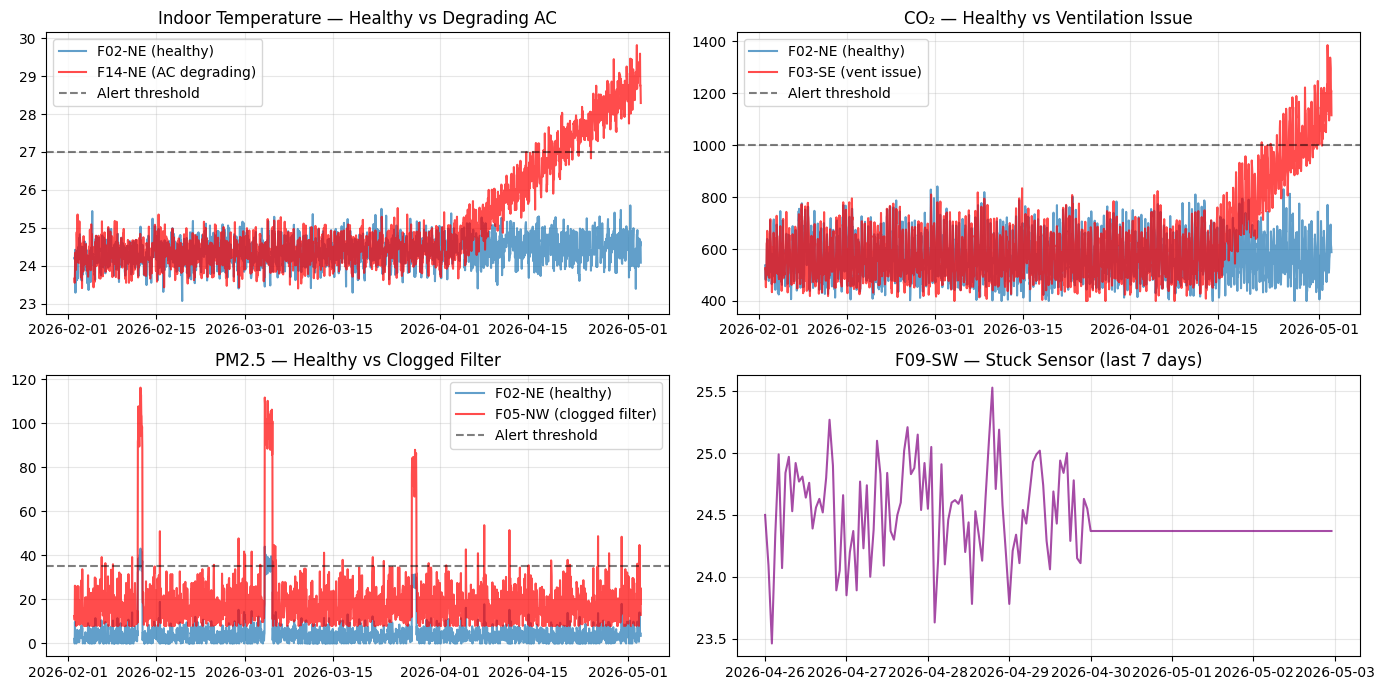

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 7))

# Healthy zone vs degrading AC zone
healthy = sensor_df[sensor_df['zone_id'] == 'F02-NE']
failing_ac = sensor_df[sensor_df['zone_id'] == 'F14-NE']
axes[0, 0].plot(healthy['timestamp'], healthy['indoor_temp'], label='F02-NE (healthy)', alpha=0.7)
axes[0, 0].plot(failing_ac['timestamp'], failing_ac['indoor_temp'], label='F14-NE (AC degrading)', alpha=0.7, color='red')
axes[0, 0].axhline(27, color='black', linestyle='--', alpha=0.5, label='Alert threshold')
axes[0, 0].set_title('Indoor Temperature — Healthy vs Degrading AC')
axes[0, 0].legend(); axes[0, 0].grid(alpha=0.3)

# Healthy CO2 vs ventilation problem
healthy_co2 = sensor_df[sensor_df['zone_id'] == 'F02-NE']
bad_vent = sensor_df[sensor_df['zone_id'] == 'F03-SE']
axes[0, 1].plot(healthy_co2['timestamp'], healthy_co2['co2'], label='F02-NE (healthy)', alpha=0.7)
axes[0, 1].plot(bad_vent['timestamp'], bad_vent['co2'], label='F03-SE (vent issue)', alpha=0.7, color='red')
axes[0, 1].axhline(1000, color='black', linestyle='--', alpha=0.5, label='Alert threshold')
axes[0, 1].set_title('CO₂ — Healthy vs Ventilation Issue')
axes[0, 1].legend(); axes[0, 1].grid(alpha=0.3)

# Healthy PM2.5 vs clogged filter
healthy_pm = sensor_df[sensor_df['zone_id'] == 'F02-NE']
clogged = sensor_df[sensor_df['zone_id'] == 'F05-NW']
axes[1, 0].plot(healthy_pm['timestamp'], healthy_pm['pm25'], label='F02-NE (healthy)', alpha=0.7)
axes[1, 0].plot(clogged['timestamp'], clogged['pm25'], label='F05-NW (clogged filter)', alpha=0.7, color='red')
axes[1, 0].axhline(35, color='black', linestyle='--', alpha=0.5, label='Alert threshold')
axes[1, 0].set_title('PM2.5 — Healthy vs Clogged Filter')
axes[1, 0].legend(); axes[1, 0].grid(alpha=0.3)

# Stuck sensor
stuck = sensor_df[sensor_df['zone_id'] == 'F09-SW'].tail(168)  # last 7 days
axes[1, 1].plot(stuck['timestamp'], stuck['indoor_temp'], color='purple', alpha=0.7)
axes[1, 1].set_title('F09-SW — Stuck Sensor (last 7 days)')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout(); plt.show()